## 98. Report Figures
0. Packages
1. Settings
2. Read Data
3. Plot Input
4. Plot Processing Area and Tiles
5. Plot Intertidal Bathymetry
6. Plot Post-Processing

### 0. Packages

In [ ]:
# Packages
import colormaps as cmaps
import glob
import geopandas as gpd
import matplotlib as mpl
import numpy as np
import os
import rioxarray as rxr
from rioxarray.merge import merge_arrays
import xarray as xr

from resilientplotterclass import rpclass


### 1. Settings

In [2]:
# File paths gtsm
file_path_gtsm_combined_zarr = r'p:\1230882-emodnet_hrsm\GTSMv3.0EMODnet\CMEMS_intertidal_SDB\zarr_files\gtsm_model_his_combined_v2.zarr'
file_path_gtsm_stations_parquet = r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\02_gtsm_files\gtsm_stations_v2.parquet'

# File paths gebco
file_path_gebco_tif = r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\03_gebco_files\gebco_2024.tif'
file_path_gebco_hat_lat_tif = r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\03_gebco_files\gebco_2024_hat_lat.tif'

# File paths feasibility map
file_path_fm_parquet = r'p:\11209821-cmems-global-sdb\00_miscellaneous\Feasibility_maps\2024\gebco_2024_latminus2_merge_result.parquet'
file_path_fm_ed_parquet = r'p:\11209821-cmems-global-sdb\00_miscellaneous\Feasibility_maps\2024\gebco_2024_latminus2_merge_result_erosion_dilation.parquet'

# File paths tiles
file_path_tiles_parquet = r'p:\11209821-cmems-global-sdb\00_miscellaneous\AOI_polygons_world\df_boxes_world_Z10_filtered_v2.parquet'

# File paths osm
file_path_osm_tifs = glob.glob(r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\00_osm_files\water_rasters\*.tif')
file_path_osm_parquet = r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\00_osm_files\geometries\osm_water_metadata.parquet'

In [3]:
# Define guidelines
gls = {
    'general':
        {'crs': 'EPSG:4326',
         'cartopy_bounds': [3.5, 7, 51, 54],
         'cartopy_features': ['land', 'ocean', 'lakes', 'coastline', 'borders']},
    'geom_style':
        {'gtsm': {'color': 'blue', 'markersize': 10, 'label': 'GTSM stations'},
         'tiles': {'facecolor': 'none', 'edgecolor': 'black', 'linewidth': 1.5, 'label': 'Tiles'},
         'feasibility_map': {'facecolor': 'blue', 'edgecolor': 'None', 'alpha': 0.25, 'linewidth': 1.5, 'label': 'Feasibility map'},
         'feasibility_map_ed': {'facecolor': 'red', 'edgecolor': 'None', 'alpha': 0.25, 'linewidth': 1.5, 'label': 'Feasibility map (erosion-dilation)'},
         'tiles nearest distance': {'column': 'nearest_station_distance', 'vmin': 0, 'vmax': 50, 'cmap': 'Greens_r', 'alpha': 0.5, 'legend': True, 'legend_kwds': {'label': 'Distance to nearest GTSM station [km]'}, 'append_axes_kwargs': {'position': 'right', 'size': 0.2, 'pad': 0.2}},
         'tiles intertidal coverage': {'column': 'intertidal_coverage', 'vmin': 0, 'vmax': 100, 'cmap': 'Greens', 'alpha': 0.5, 'legend': True, 'legend_kwds': {'label': 'Intertidal coverage [%]'}, 'append_axes_kwargs': {'position': 'right', 'size': 0.2, 'pad': 0.2}},
         'tiles filtered': {'facecolor': 'none', 'edgecolor': 'red', 'linewidth': 1.5, 'label': 'Filtered tiles'}},
    'extent_style':
        {'waddenzee': {'xlim': [4.5703125 - 0.02, 5.625 + 0.02], 'ylim': [52.90890205 - 0.02, 53.54030739 + 0.02]},
         'netherlands': {'xlim': [3.5, 7], 'ylim': [51, 54]},
         'europe': {'xlim': [-10, 10], 'ylim': [40, 60]},
         'global': {'xlim': [-180, 180], 'ylim': [-90, 90]}},
    }

# Set guidelines
rpc = rpclass(gls)

# Get guidelines
gls = rpc.get_guidelines()

# Get bounds and crs
crs = gls['general']['crs']
bounds = gls['general']['cartopy_bounds']

# Show guidelines
rpc.show_guidelines(open=False)

### 2. Read Data

In [4]:
# Read gtsm
ds_gtsm_combined = xr.open_zarr(file_path_gtsm_combined_zarr, consolidated=True)
gdf_gtsm_stations = gpd.read_parquet(file_path_gtsm_stations_parquet)

# Read gebco
ds_gebco = rxr.open_rasterio(file_path_gebco_tif, masked=True).squeeze()
ds_gebco_hat_lat = rxr.open_rasterio(file_path_gebco_hat_lat_tif, masked=True)

# Read feasibility map
gdf_fm = gpd.read_parquet(file_path_fm_parquet)
gdf_fm_ed = gpd.read_parquet(file_path_fm_ed_parquet)

# Read tiles
gdf_tiles = gpd.read_parquet(file_path_tiles_parquet)
gdf_tiles['nearest_station_distance'] = gdf_tiles['nearest_station_distance']/1000  # Convert to km
gdf_tiles['intertidal_coverage'] = gdf_tiles['intertidal_coverage']*100  # Convert to percentage
gdf_tiles['intertidal_coverage_ed'] = gdf_tiles['intertidal_coverage_ed']*100  # Convert to percentage
gdf_tiles['processed'] = (gdf_tiles['nearest_station_distance'] <= 37) & (gdf_tiles['intertidal_coverage'] >= 1) & (gdf_tiles['intertidal_coverage_ed'] > 0)
print('Number of tiles:', len(gdf_tiles))
print(gdf_tiles['processed'].value_counts())

# Read osm
gdf_osm = gpd.read_parquet(file_path_osm_parquet)

Number of tiles: 38639
processed
False    19842
True     18797
Name: count, dtype: int64


In [5]:
# Clip data
extents = gls['extent_style']
bounds_wz = [extents['waddenzee']['xlim'][0], extents['waddenzee']['ylim'][0], extents['waddenzee']['xlim'][1], extents['waddenzee']['ylim'][1]]
bounds_nl = [extents['netherlands']['xlim'][0], extents['netherlands']['ylim'][0], extents['netherlands']['xlim'][1], extents['netherlands']['ylim'][1]]
bounds_eu = [extents['europe']['xlim'][0], extents['europe']['ylim'][0], extents['europe']['xlim'][1], extents['europe']['ylim'][1]]

gdf_gtsm_stations_wz = gdf_gtsm_stations.cx[bounds_wz[0]:bounds_wz[2], bounds_wz[1]:bounds_wz[3]]
ds_gebco_wz          = ds_gebco.rio.clip_box(minx=bounds_wz[0], miny=bounds_wz[1], maxx=bounds_wz[2], maxy=bounds_wz[3], crs=crs)
ds_gebco_hat_lat_wz = ds_gebco_hat_lat.rio.clip_box(minx=bounds_wz[0], miny=bounds_wz[1], maxx=bounds_wz[2], maxy=bounds_wz[3], crs=crs)
gdf_fm_wz            = gdf_fm.cx[bounds_wz[0]:bounds_wz[2], bounds_wz[1]:bounds_wz[3]]
gdf_fm_ed_wz         = gdf_fm_ed.cx[bounds_wz[0]:bounds_wz[2], bounds_wz[1]:bounds_wz[3]]
gdf_tiles_wz         = gdf_tiles.cx[bounds_wz[0]:bounds_wz[2], bounds_wz[1]:bounds_wz[3]]
gdf_osm_wz           = gdf_osm.cx[bounds_wz[0]:bounds_wz[2], bounds_wz[1]:bounds_wz[3]]
ds_osm_wz_ls         = [rxr.open_rasterio(file_path, masked=True).squeeze() for file_path in gdf_osm_wz['file_path'].values]
ds_osm_wz            = merge_arrays(ds_osm_wz_ls).rio.clip_box(minx=bounds_wz[0], miny=bounds_wz[1], maxx=bounds_wz[2], maxy=bounds_wz[3], crs=crs).astype('int32')

gdf_gtsm_stations_nl = gdf_gtsm_stations.cx[bounds_nl[0]:bounds_nl[2], bounds_nl[1]:bounds_nl[3]]
ds_gebco_nl          = ds_gebco.rio.clip_box(minx=bounds_nl[0], miny=bounds_nl[1], maxx=bounds_nl[2], maxy=bounds_nl[3], crs=crs)
ds_gebco_hat_lat_nl = ds_gebco_hat_lat.rio.clip_box(minx=bounds_nl[0], miny=bounds_nl[1], maxx=bounds_nl[2], maxy=bounds_nl[3], crs=crs)
gdf_fm_nl            = gdf_fm.cx[bounds_nl[0]:bounds_nl[2], bounds_nl[1]:bounds_nl[3]]
gdf_fm_ed_nl         = gdf_fm_ed.cx[bounds_nl[0]:bounds_nl[2], bounds_nl[1]:bounds_nl[3]]
gdf_tiles_nl         = gdf_tiles.cx[bounds_nl[0]:bounds_nl[2], bounds_nl[1]:bounds_nl[3]]
gdf_osm_nl           = gdf_osm.cx[bounds_nl[0]:bounds_nl[2], bounds_nl[1]:bounds_nl[3]]
ds_osm_nl_ls         = [rxr.open_rasterio(file_path, masked=True).squeeze() for file_path in gdf_osm_nl['file_path'].values]
ds_osm_nl            = merge_arrays(ds_osm_nl_ls).rio.clip_box(minx=bounds_nl[0], miny=bounds_nl[1], maxx=bounds_nl[2], maxy=bounds_nl[3], crs=crs).astype('int32')

gdf_gtsm_stations_eu = gdf_gtsm_stations.cx[bounds_eu[0]:bounds_eu[2], bounds_eu[1]:bounds_eu[3]]
ds_gebco_eu          = ds_gebco.rio.clip_box(minx=bounds_eu[0], miny=bounds_eu[1], maxx=bounds_eu[2], maxy=bounds_eu[3], crs=crs)
ds_gebco_hat_lat_eu = ds_gebco_hat_lat.rio.clip_box(minx=bounds_eu[0], miny=bounds_eu[1], maxx=bounds_eu[2], maxy=bounds_eu[3], crs=crs)
gdf_fm_eu            = gdf_fm.cx[bounds_eu[0]:bounds_eu[2], bounds_eu[1]:bounds_eu[3]]
gdf_fm_ed_eu         = gdf_fm_ed.cx[bounds_eu[0]:bounds_eu[2], bounds_eu[1]:bounds_eu[3]]
gdf_tiles_eu         = gdf_tiles.cx[bounds_eu[0]:bounds_eu[2], bounds_eu[1]:bounds_eu[3]]
gdf_osm_eu           = gdf_osm.cx[bounds_eu[0]:bounds_eu[2], bounds_eu[1]:bounds_eu[3]]
ds_osm_eu_ls         = [rxr.open_rasterio(file_path, masked=True).squeeze() for file_path in gdf_osm_eu['file_path'].values]
ds_osm_eu_ls         = [ds.astype('float').rio.reproject(dst_crs=crs, resolution=ds.rio.resolution()[0]*10) for ds in ds_osm_eu_ls]
ds_osm_eu            = merge_arrays(ds_osm_eu_ls).rio.clip_box(minx=bounds_eu[0], miny=bounds_eu[1], maxx=bounds_eu[2], maxy=bounds_eu[3], crs=crs).astype('int32')

c:\Users\white_rn\AppData\Local\miniforge3\envs\rpc_env\Lib\site-packages\IPython\core\interactiveshell.py:3517: SerializationWarning: saving variable None with floating point data as an integer dtype without any _FillValue to use for NaNs
  if await self.run_code(code, result, async_=asy):
c:\Users\white_rn\AppData\Local\miniforge3\envs\rpc_env\Lib\site-packages\IPython\core\interactiveshell.py:3517: SerializationWarning: saving variable None with floating point data as an integer dtype without any _FillValue to use for NaNs
  if await self.run_code(code, result, async_=asy):


### 3. Plot Inputs

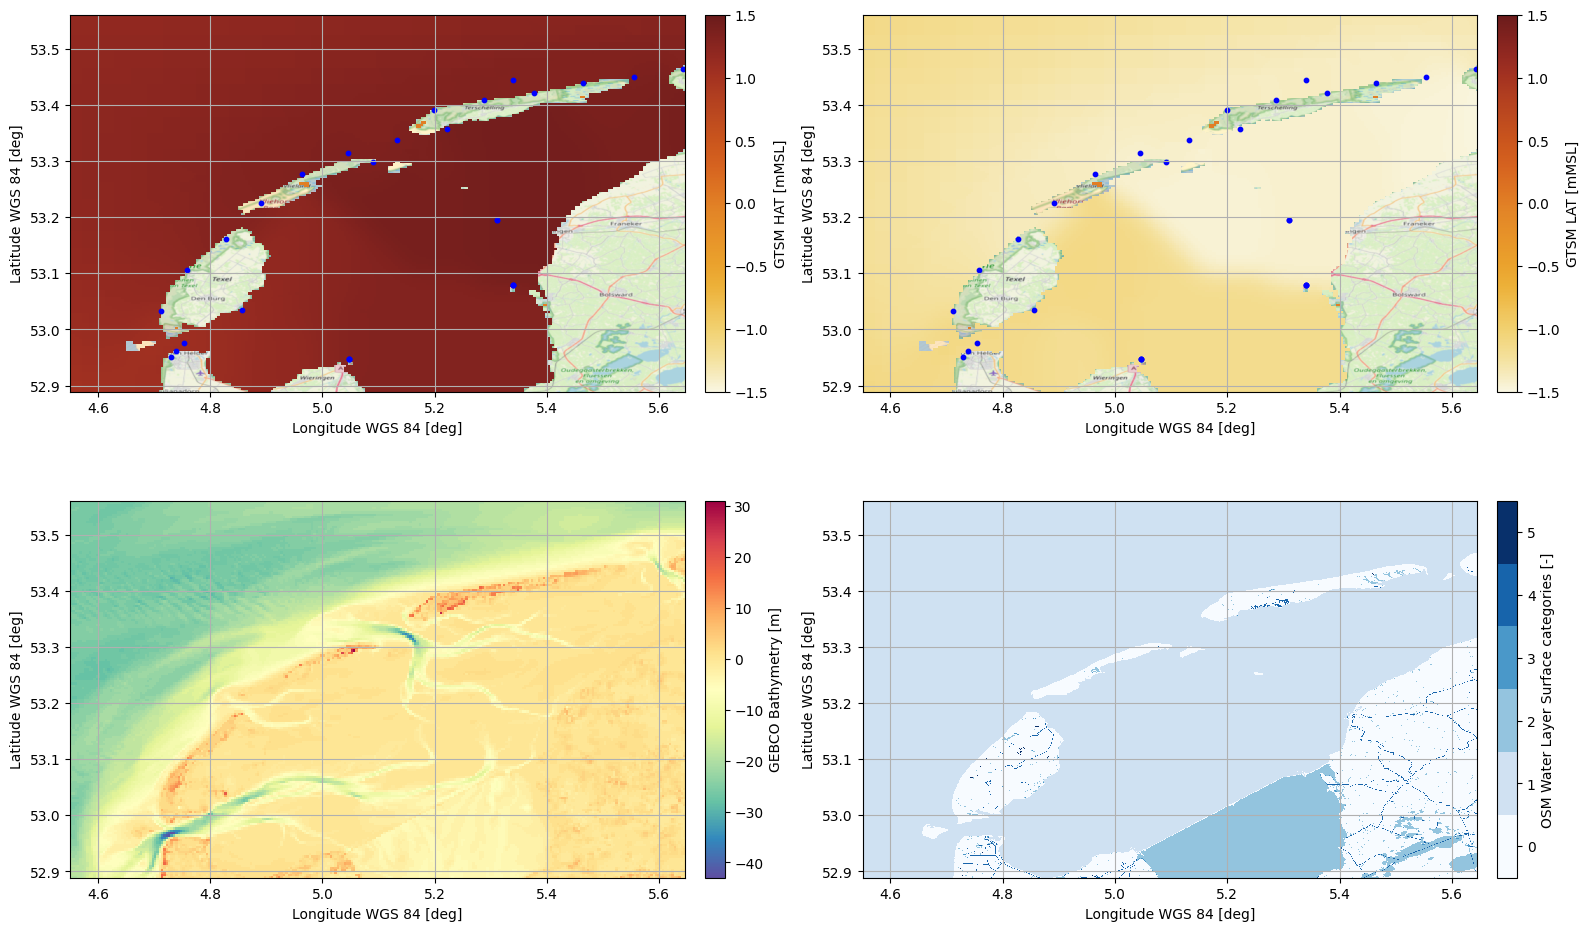

In [10]:
fig, axs = rpc.subplots(2, 2, figsize=(16, 10))
axs = axs.flatten()
rpc.imshow(ds_gebco_hat_lat_wz.isel(band=0), ax=axs[0], data_style='default', vmin=-1.5, vmax=1.5, cmap=cmaps.red2b, cbar_kwargs={'label': 'GTSM HAT [mMSL]'})
rpc.imshow(ds_gebco_hat_lat_wz.isel(band=1), ax=axs[1], data_style='default', vmin=-1.5, vmax=1.5, cmap=cmaps.red2b, cbar_kwargs={'label': 'GTSM LAT [mMSL]'})
rpc.geometries(gdf_gtsm_stations_wz, ax=axs[0], geom_style='gtsm')
rpc.geometries(gdf_gtsm_stations_wz, ax=axs[1], geom_style='gtsm')
rpc.imshow(ds_gebco_wz, ax=axs[2], data_style='default', cmap='Spectral_r', cbar_kwargs={'label': 'GEBCO Bathymetry [m]'})
p = rpc.imshow(ds_osm_wz, ax=axs[3], data_style='default', vmin=-0.5, vmax=5.5,
               cmap=mpl.colormaps['Blues'].resampled(6), cbar_kwargs={'label': 'OSM Water Layer Surface categories [-]'})
p.colorbar.set_ticks(range(0, 6))
for ax in axs:
    rpc.basemap(crs=crs, ax=ax, map_style='osm', extent_style='waddenzee')
rpc.show(fig=fig)

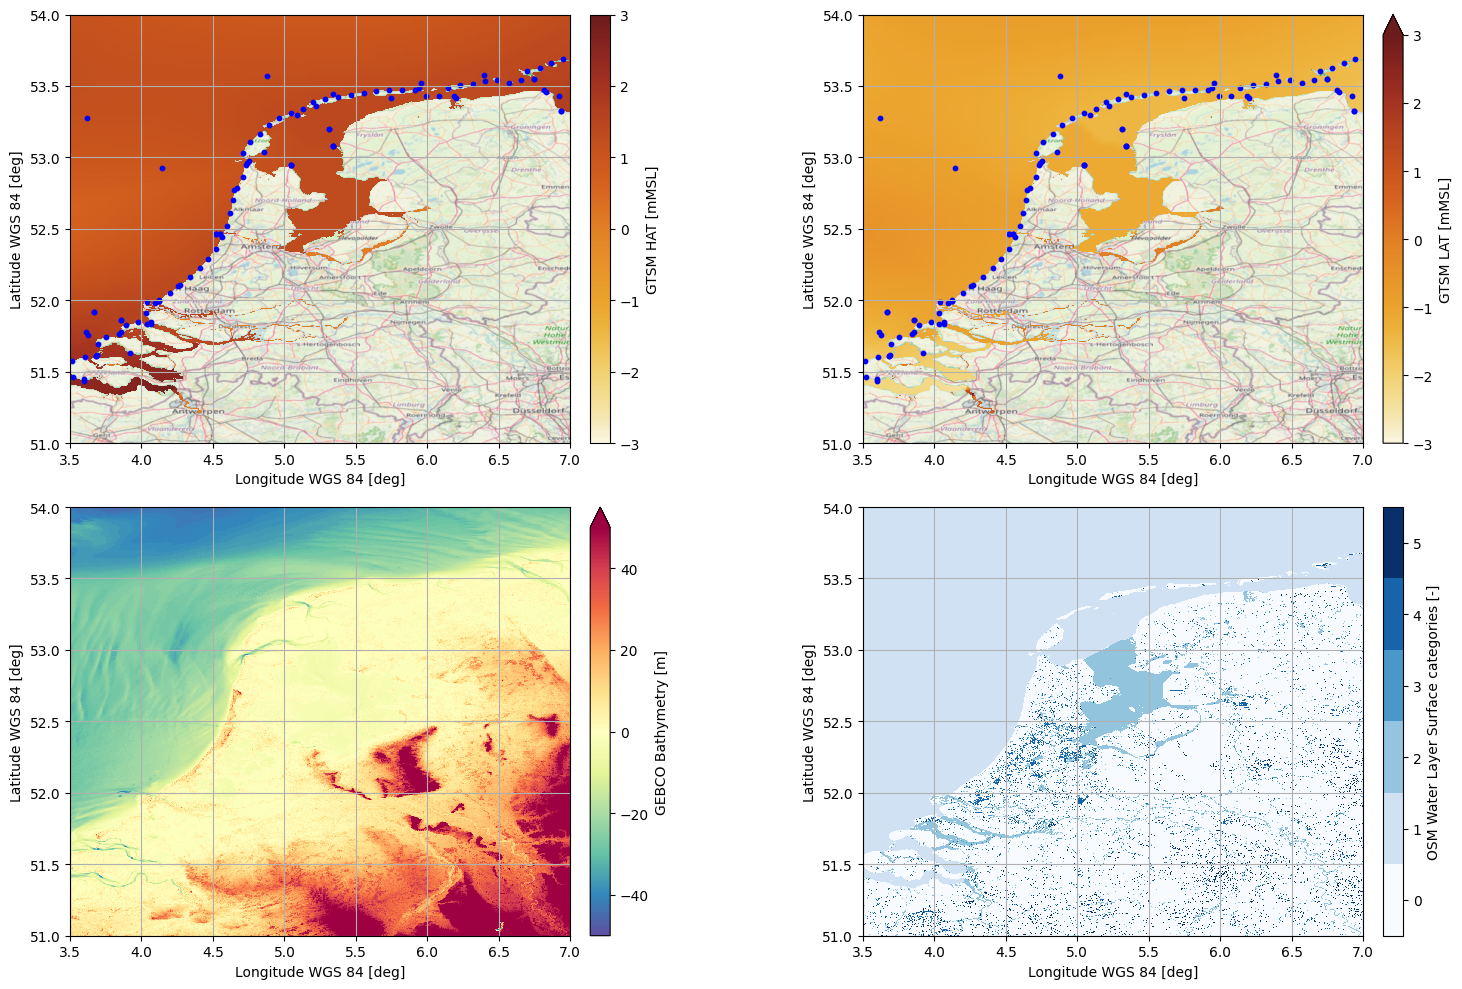

In [14]:
fig, axs = rpc.subplots(2, 2, figsize=(16, 10))
axs = axs.flatten()
rpc.imshow(ds_gebco_hat_lat_nl.isel(band=0), ax=axs[0], data_style='default', vmin=-3, vmax=3, cmap=cmaps.red2b, cbar_kwargs={'label': 'GTSM HAT [mMSL]'})
rpc.imshow(ds_gebco_hat_lat_nl.isel(band=1), ax=axs[1], data_style='default', vmin=-3, vmax=3, cmap=cmaps.red2b, cbar_kwargs={'label': 'GTSM LAT [mMSL]'})
rpc.geometries(gdf_gtsm_stations_nl, ax=axs[0], geom_style='gtsm')
rpc.geometries(gdf_gtsm_stations_nl, ax=axs[1], geom_style='gtsm')
rpc.imshow(ds_gebco_nl, ax=axs[2], data_style='default', vmin=-50, vmax=50, cmap='Spectral_r', cbar_kwargs={'label': 'GEBCO Bathymetry [m]'})
p = rpc.imshow(ds_osm_nl, ax=axs[3], data_style='default', vmin=-0.5, vmax=5.5,
              cmap=mpl.colormaps['Blues'].resampled(6), cbar_kwargs={'label': 'OSM Water Layer Surface categories [-]'})
p.colorbar.set_ticks(range(0, 6))
for ax in axs:
    rpc.basemap(crs=crs, ax=ax, map_style='osm', extent_style='netherlands')
rpc.show(fig=fig)

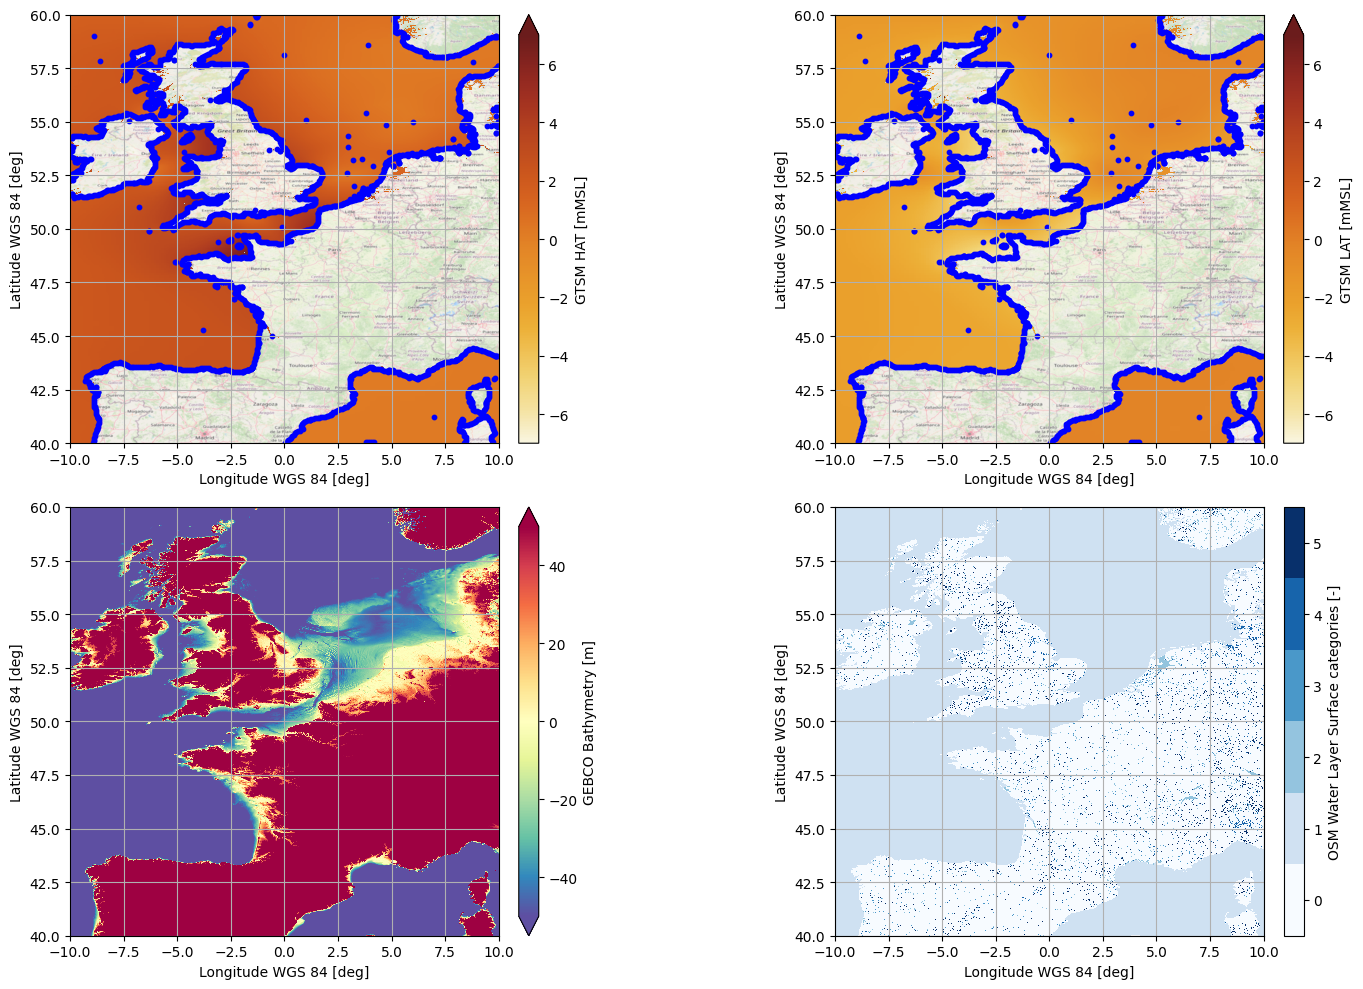

In [15]:
fig, axs = rpc.subplots(2, 2, figsize=(16, 10))
axs = axs.flatten()
rpc.imshow(ds_gebco_hat_lat_eu.isel(band=0), ax=axs[0], data_style='default', vmin=-7, vmax=7, cmap=cmaps.red2b, cbar_kwargs={'label': 'GTSM HAT [mMSL]'})
rpc.imshow(ds_gebco_hat_lat_eu.isel(band=1), ax=axs[1], data_style='default', vmin=-7, vmax=7, cmap=cmaps.red2b, cbar_kwargs={'label': 'GTSM LAT [mMSL]'})
rpc.geometries(gdf_gtsm_stations_eu, ax=axs[0], geom_style='gtsm')
rpc.geometries(gdf_gtsm_stations_eu, ax=axs[1], geom_style='gtsm')
rpc.imshow(ds_gebco_eu, ax=axs[2], data_style='default', vmin=-50, vmax=50, cmap='Spectral_r', cbar_kwargs={'label': 'GEBCO Bathymetry [m]'})
p = rpc.imshow(ds_osm_eu, ax=axs[3], data_style='default', vmin=-0.5, vmax=5.5,
              cmap=mpl.colormaps['Blues'].resampled(6), cbar_kwargs={'label': 'OSM Water Layer Surface categories [-]'})
p.colorbar.set_ticks(range(0, 6))
for ax in axs:
    rpc.basemap(crs=crs, ax=ax, map_style='osm', extent_style='europe')
rpc.show(fig=fig)

### 4. Plot Processing Area and Tiles

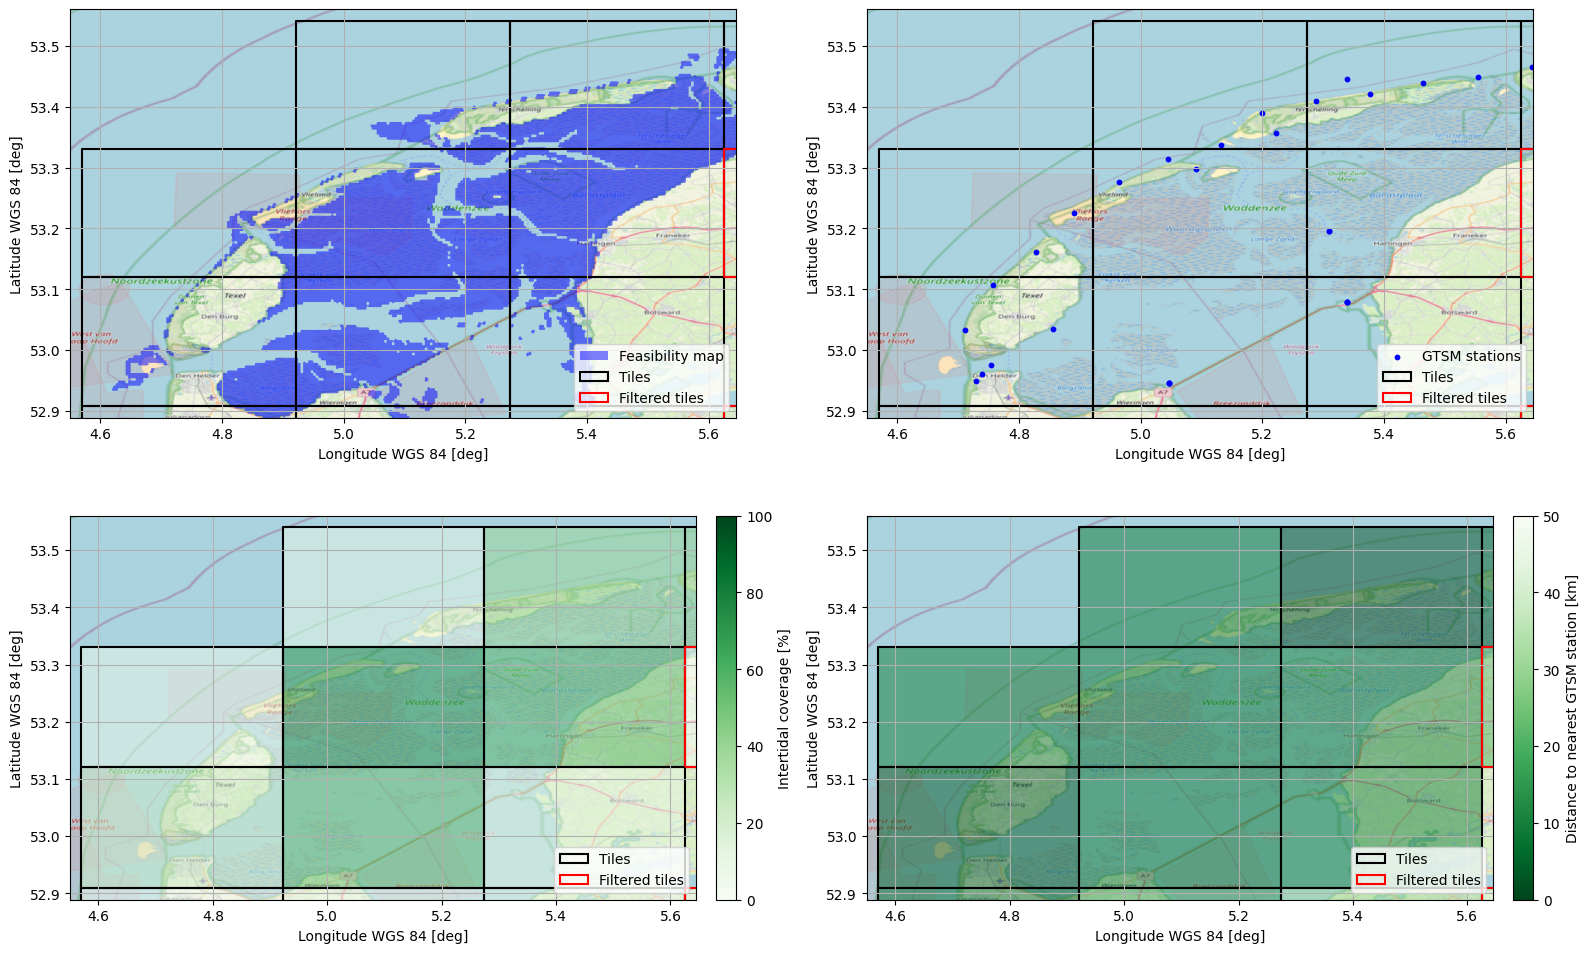

In [9]:
fig, axs = rpc.subplots(2, 2, figsize=(16, 10))
axs = axs.flatten()
#rpc.geometries(gdf_fm_wz, ax=axs[1], geom_style='feasibility_map')
rpc.geometries(gdf_fm_ed_wz, ax=axs[0], geom_style='feasibility_map', alpha=0.5)
rpc.geometries(gdf_gtsm_stations_wz, ax=axs[1], geom_style='gtsm')
rpc.geometries(gdf_tiles_wz, ax=axs[2], geom_style='tiles intertidal coverage')
rpc.geometries(gdf_tiles_wz, ax=axs[3], geom_style='tiles nearest distance')
for ax in axs:
    rpc.geometries(gdf_tiles_wz, ax=ax, geom_style='tiles')
    rpc.geometries(gdf_tiles_wz[~gdf_tiles_wz['processed']], ax=ax, geom_style='tiles filtered')
    rpc.basemap(crs=crs, ax=ax, map_style='osm', extent_style='waddenzee')
    ax.legend(loc='lower right')
rpc.show(fig=fig)

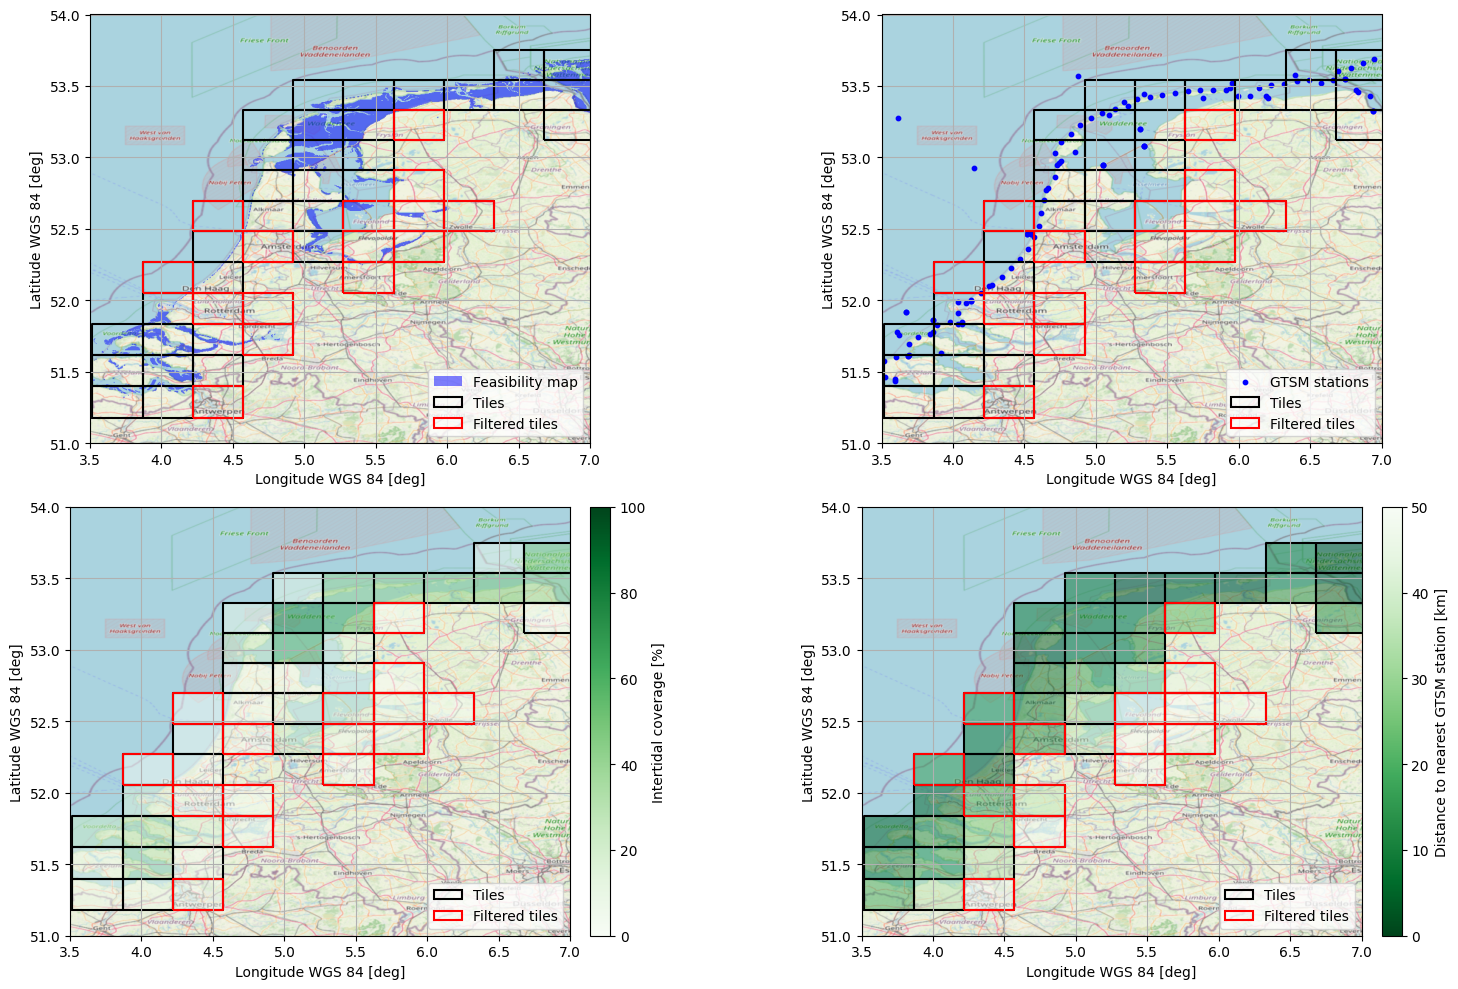

In [10]:
fig, axs = rpc.subplots(2, 2, figsize=(16, 10))
axs = axs.flatten()
#rpc.geometries(gdf_fm_nl, ax=axs[1], geom_style='feasibility_map')
rpc.geometries(gdf_fm_ed_nl, ax=axs[0], geom_style='feasibility_map', alpha=0.5)
rpc.geometries(gdf_gtsm_stations_nl, ax=axs[1], geom_style='gtsm')
rpc.geometries(gdf_tiles_nl, ax=axs[2], geom_style='tiles intertidal coverage')
rpc.geometries(gdf_tiles_nl, ax=axs[3], geom_style='tiles nearest distance')
for ax in axs:
    rpc.geometries(gdf_tiles_nl, ax=ax, geom_style='tiles')
    rpc.geometries(gdf_tiles_nl[~gdf_tiles_nl['processed']], ax=ax, geom_style='tiles filtered')
    rpc.basemap(crs=crs, ax=ax, map_style='osm', extent_style='netherlands')
    ax.legend(loc='lower right')
rpc.show(fig=fig)

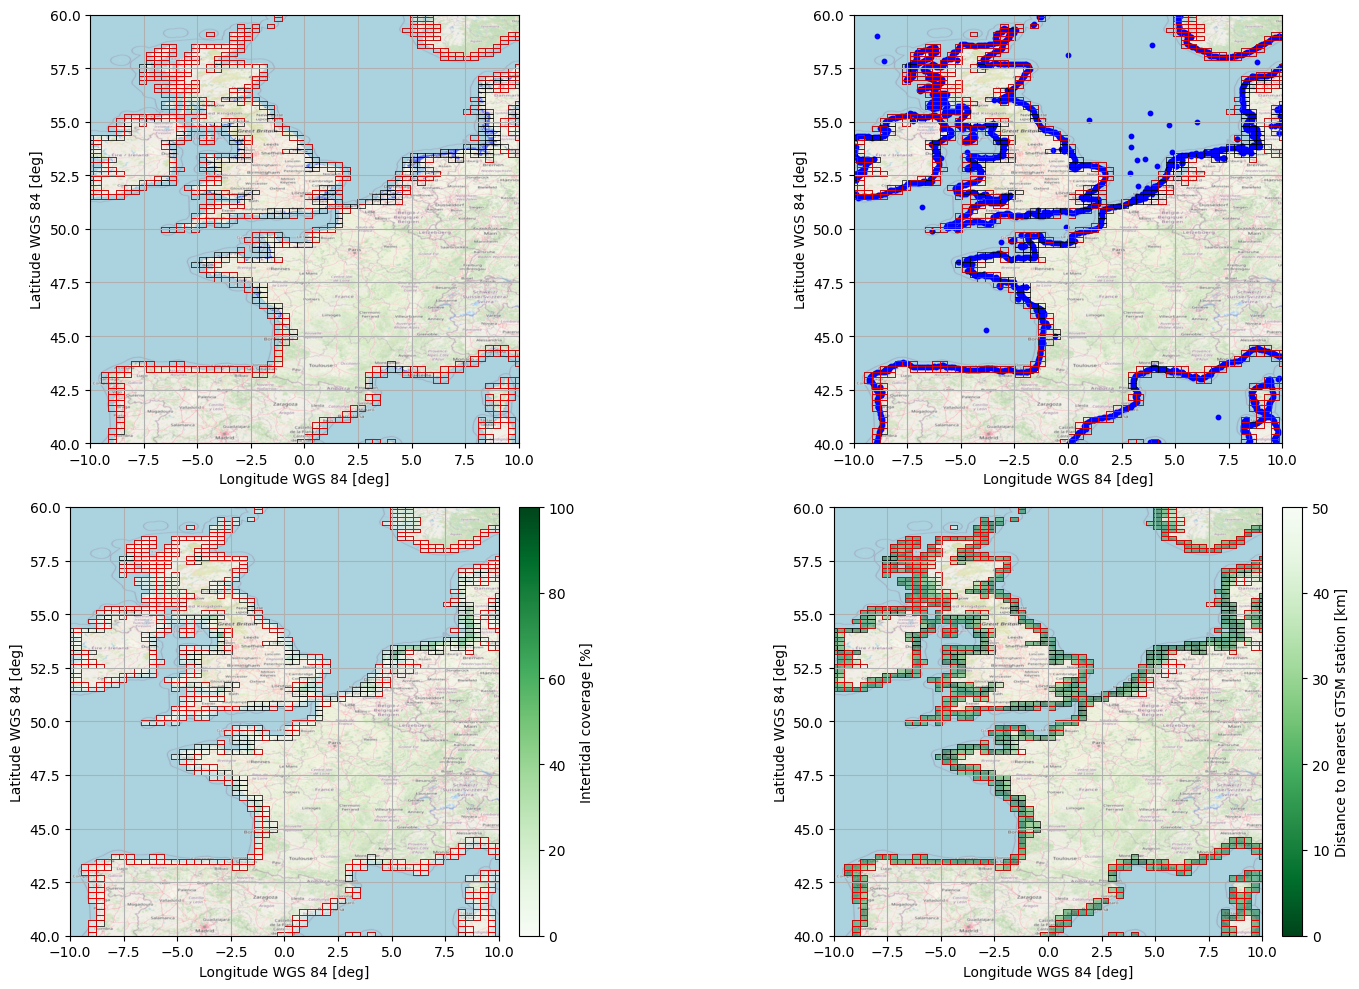

In [11]:
fig, axs = rpc.subplots(2, 2, figsize=(16, 10))
axs = axs.flatten()
#rpc.geometries(gdf_fm_eu, ax=axs[1], geom_style='feasibility_map')
rpc.geometries(gdf_fm_ed_eu, ax=axs[0], geom_style='feasibility_map', alpha=0.5)
rpc.geometries(gdf_gtsm_stations_eu, ax=axs[1], geom_style='gtsm')
rpc.geometries(gdf_tiles_eu, ax=axs[2], geom_style='tiles intertidal coverage')
rpc.geometries(gdf_tiles_eu, ax=axs[3], geom_style='tiles nearest distance')
for ax in axs:
    rpc.geometries(gdf_tiles_eu, ax=ax, geom_style='tiles', linewidth=0.5)
    rpc.geometries(gdf_tiles_eu[~gdf_tiles_eu['processed']], ax=ax, geom_style='tiles filtered', linewidth=0.5)
    rpc.basemap(crs=crs, ax=ax, map_style='osm', extent_style='europe')
rpc.show(fig=fig)

### 5. Plot Intertidal Bathymetry

In [70]:
# File paths
file_path_sdbs = glob.glob(r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\05_calibrated\intertidal_improved_100m_global\03_merged\*.tif')
file_path_sdbs = [file_path for file_path in file_path_sdbs if not file_path.endswith('.tif.aux.xml')]

gdf_sdb_wz = gdf_tiles_wz[gdf_tiles_wz['processed']].copy()
for i, row in gdf_sdb_wz.iterrows():
    file_path = [file_path for file_path in file_path_sdbs if os.path.basename(file_path).startswith(row['name'])]
    gdf_sdb_wz.at[i, 'file_path'] = file_path[0] if file_path else None
gdf_sdb_wz = gdf_sdb_wz[gdf_sdb_wz['file_path'].notna()]
ds_sdb_wz_ls = [rxr.open_rasterio(file_path, masked=True) for file_path in gdf_sdb_wz['file_path'].values]
ds_sdb_wz_ls = [ds.rio.set_nodata(np.nan) for ds in ds_sdb_wz_ls]
ds_sdb_wz   = merge_arrays(ds_sdb_wz_ls).rio.clip_box(minx=bounds_wz[0], miny=bounds_wz[1], maxx=bounds_wz[2], maxy=bounds_wz[3])

gdf_sdb_nl = gdf_tiles_nl[gdf_tiles_nl['processed']].copy()
for i, row in gdf_sdb_nl.iterrows():
    file_path = [file_path for file_path in file_path_sdbs if os.path.basename(file_path).startswith(row['name'])]
    gdf_sdb_nl.at[i, 'file_path'] = file_path[0] if file_path else None
gdf_sdb_nl = gdf_sdb_nl[gdf_sdb_nl['file_path'].notna()]
ds_sdb_nl_ls = [rxr.open_rasterio(file_path, masked=True) for file_path in gdf_sdb_nl['file_path'].values]
ds_sdb_nl_ls = [ds.rio.set_nodata(np.nan) for ds in ds_sdb_nl_ls]
ds_sdb_nl   = merge_arrays(ds_sdb_nl_ls).rio.clip_box(minx=bounds_nl[0], miny=bounds_nl[1], maxx=bounds_nl[2], maxy=bounds_nl[3])

gdf_sdb_eu = gdf_tiles_eu[gdf_tiles_eu['processed']].copy()
for i, row in gdf_sdb_eu.iterrows():
    file_path = [file_path for file_path in file_path_sdbs if os.path.basename(file_path).startswith(row['name'])]
    gdf_sdb_eu.at[i, 'file_path'] = file_path[0] if file_path else None
gdf_sdb_eu = gdf_sdb_eu[gdf_sdb_eu['file_path'].notna()]
ds_sdb_eu_ls = [rxr.open_rasterio(file_path, masked=True) for file_path in gdf_sdb_eu['file_path'].values]
ds_sdb_eu_ls = [ds.rio.set_nodata(np.nan) for ds in ds_sdb_eu_ls]
ds_sdb_eu_ls = [ds.rio.reproject(dst_crs=crs, resolution=ds.rio.resolution()[0]*100) for ds in ds_sdb_eu_ls]
ds_sdb_eu   = merge_arrays(ds_sdb_eu_ls).rio.clip_box(minx=bounds_eu[0], miny=bounds_eu[1], maxx=bounds_eu[2], maxy=bounds_eu[3])

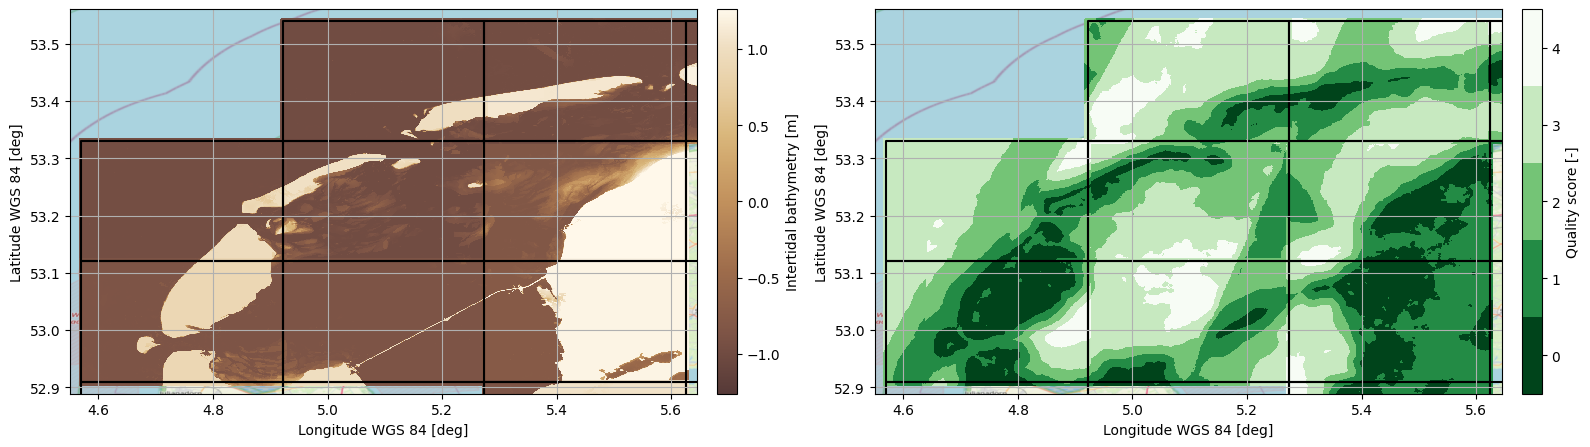

In [71]:
fig, axs = rpc.subplots(1, 2, figsize=(16, 5))
axs = axs.flatten()
rpc.imshow(ds_sdb_wz.isel(band=0), ax=axs[0], data_style='default', cmap=cmaps.brown_sable, center=0, cbar_kwargs={'label': 'Intertidal bathymetry [m]'})
p = rpc.imshow(ds_sdb_wz.isel(band=1), ax=axs[1], data_style='default', vmin=-0.5, vmax=4.5,
               cmap=mpl.colormaps['Greens_r'].resampled(5), cbar_kwargs={'label': 'Quality score [-]'})
p.colorbar.set_ticks(range(0, 5))
for ax in axs:
    rpc.geometries(gdf_tiles_wz, ax=ax, geom_style='tiles')
    rpc.basemap(crs=crs, ax=ax, map_style='osm', extent_style='waddenzee')
rpc.show(fig=fig)

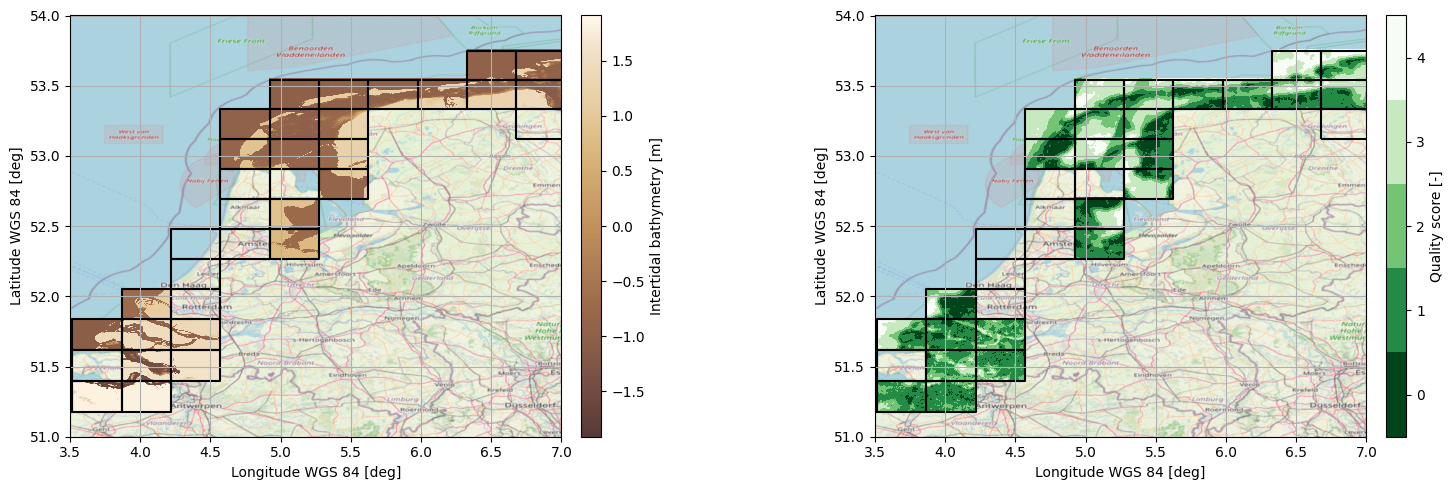

In [72]:
fig, axs = rpc.subplots(1, 2, figsize=(16, 5))
axs = axs.flatten()
rpc.imshow(ds_sdb_nl.isel(band=0), ax=axs[0], data_style='default', center=0, cmap=cmaps.brown_sable, cbar_kwargs={'label': 'Intertidal bathymetry [m]'})
p = rpc.imshow(ds_sdb_nl.isel(band=1), ax=axs[1], data_style='default', vmin=-0.5, vmax=4.5,
              cmap=mpl.colormaps['Greens_r'].resampled(5), cbar_kwargs={'label': 'Quality score [-]'})
p.colorbar.set_ticks(range(0, 5))
for ax in axs:
    rpc.geometries(gdf_tiles_nl[gdf_tiles_nl['processed']], ax=ax, geom_style='tiles')
    rpc.basemap(crs=crs, ax=ax, map_style='osm', extent_style='netherlands')
rpc.show(fig=fig)

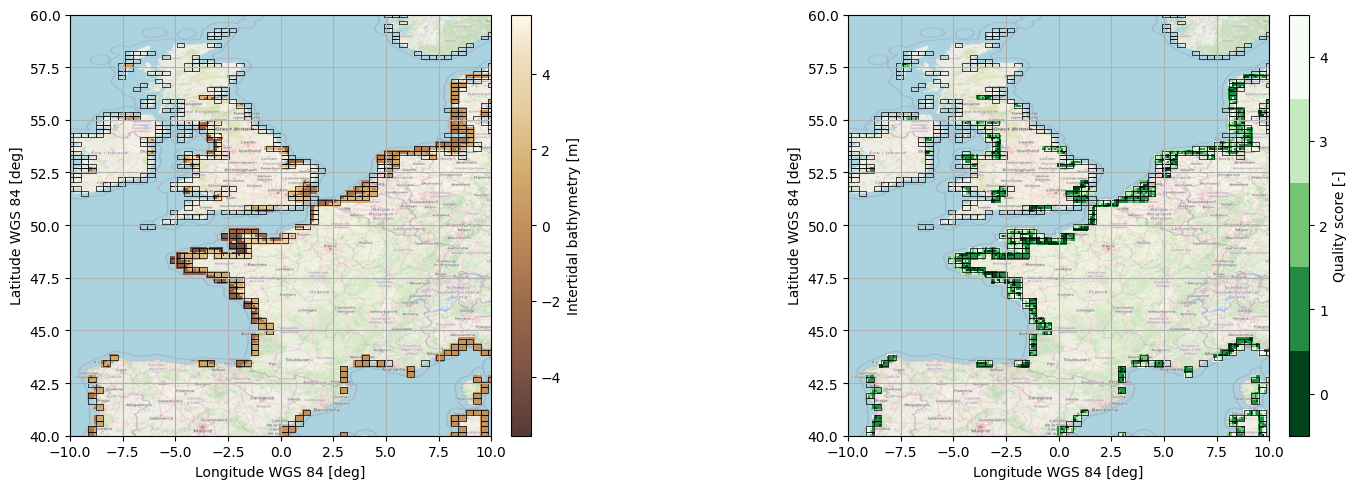

In [73]:
fig, axs = rpc.subplots(1, 2, figsize=(16, 5))
axs = axs.flatten()
rpc.imshow(ds_sdb_eu.isel(band=0), ax=axs[0], data_style='default', center=0, cmap=cmaps.brown_sable, cbar_kwargs={'label': 'Intertidal bathymetry [m]'})
p = rpc.imshow(ds_sdb_eu.isel(band=1), ax=axs[1], data_style='default', vmin=-0.5, vmax=4.5,
              cmap=mpl.colormaps['Greens_r'].resampled(5), cbar_kwargs={'label': 'Quality score [-]'})
p.colorbar.set_ticks(range(0, 5))
for ax in axs:
    rpc.geometries(gdf_tiles_eu[gdf_tiles_eu['processed']], ax=ax, geom_style='tiles', linewidth=0.5)
    rpc.basemap(crs=crs, ax=ax, map_style='osm', extent_style='europe')
rpc.show(fig=fig)

### 6. Plot Post-Processing

In [74]:
# File paths
file_path_sdbs = glob.glob(r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\05_calibrated\intertidal_improved_100m_global\05_reprojected\*.tif')
file_path_sdbs = [file_path for file_path in file_path_sdbs if not file_path.endswith('.tif.aux.xml')]

gdf_sdb_wz = gdf_tiles_wz.copy()
for i, row in gdf_sdb_wz.iterrows():
    file_path = [file_path for file_path in file_path_sdbs if os.path.basename(file_path).startswith(row['name'])]
    gdf_sdb_wz.at[i, 'file_path'] = file_path[0] if file_path else None
gdf_sdb_wz = gdf_sdb_wz[gdf_sdb_wz['file_path'].notna()]
ds_sdb_wz_ls = [rxr.open_rasterio(file_path, masked=True) for file_path in gdf_sdb_wz['file_path'].values]
ds_sdb_wz_ls = [ds.rio.set_nodata(np.nan) for ds in ds_sdb_wz_ls]
ds_sdb_wz   = merge_arrays(ds_sdb_wz_ls).rio.clip_box(minx=bounds_wz[0], miny=bounds_wz[1], maxx=bounds_wz[2], maxy=bounds_wz[3])

gdf_sdb_nl = gdf_tiles_nl.copy()
for i, row in gdf_sdb_nl.iterrows():
    file_path = [file_path for file_path in file_path_sdbs if os.path.basename(file_path).startswith(row['name'])]
    gdf_sdb_nl.at[i, 'file_path'] = file_path[0] if file_path else None
gdf_sdb_nl = gdf_sdb_nl[gdf_sdb_nl['file_path'].notna()]
ds_sdb_nl_ls = [rxr.open_rasterio(file_path, masked=True) for file_path in gdf_sdb_nl['file_path'].values]
ds_sdb_nl_ls = [ds.rio.set_nodata(np.nan) for ds in ds_sdb_nl_ls]
ds_sdb_nl   = merge_arrays(ds_sdb_nl_ls).rio.clip_box(minx=bounds_nl[0], miny=bounds_nl[1], maxx=bounds_nl[2], maxy=bounds_nl[3])

gdf_sdb_eu = gdf_tiles_eu.copy()
for i, row in gdf_sdb_eu.iterrows():
    file_path = [file_path for file_path in file_path_sdbs if os.path.basename(file_path).startswith(row['name'])]
    gdf_sdb_eu.at[i, 'file_path'] = file_path[0] if file_path else None
gdf_sdb_eu = gdf_sdb_eu[gdf_sdb_eu['file_path'].notna()]
ds_sdb_eu_ls = [rxr.open_rasterio(file_path, masked=True) for file_path in gdf_sdb_eu['file_path'].values]
ds_sdb_eu_ls = [ds.rio.set_nodata(np.nan) for ds in ds_sdb_eu_ls]
ds_sdb_eu_ls = [ds.rio.reproject(dst_crs=crs, resolution=ds.rio.resolution()[0]*100) for ds in ds_sdb_eu_ls]
ds_sdb_eu   = merge_arrays(ds_sdb_eu_ls).rio.clip_box(minx=bounds_eu[0], miny=bounds_eu[1], maxx=bounds_eu[2], maxy=bounds_eu[3])

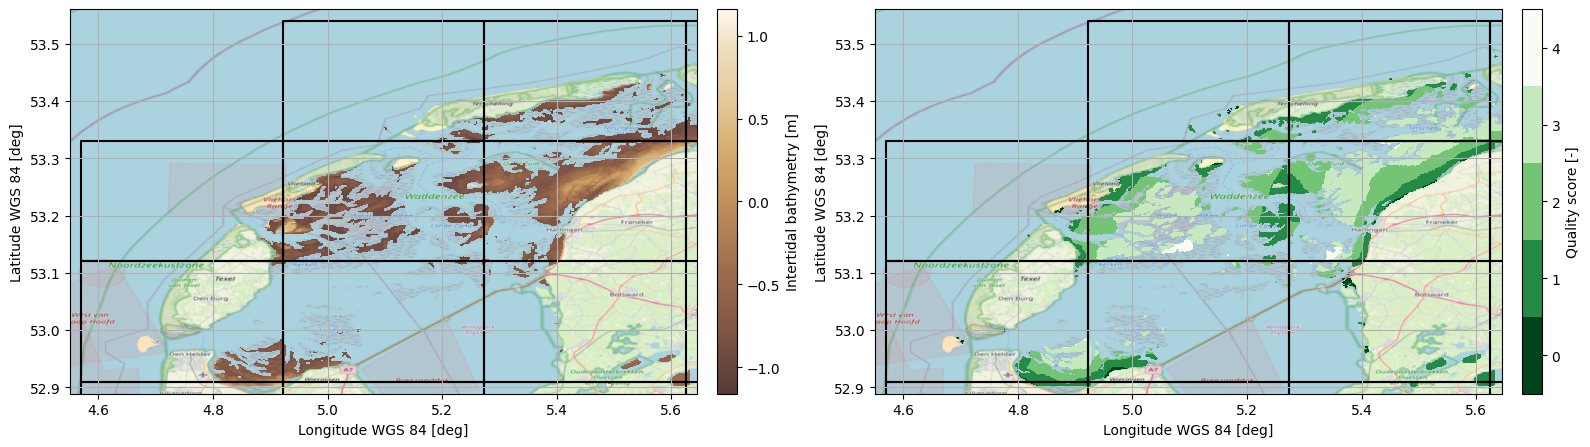

In [75]:
fig, axs = rpc.subplots(1, 2, figsize=(16, 5))
axs = axs.flatten()
rpc.imshow(ds_sdb_wz.isel(band=0), ax=axs[0], data_style='default', center=0, cmap=cmaps.brown_sable, cbar_kwargs={'label': 'Intertidal bathymetry [m]'})
p = rpc.imshow(ds_sdb_wz.isel(band=1), ax=axs[1], data_style='default', vmin=-0.5, vmax=4.5,
              cmap=mpl.colormaps['Greens_r'].resampled(5), cbar_kwargs={'label': 'Quality score [-]'})
p.colorbar.set_ticks(range(0, 5))
for ax in axs:
    rpc.geometries(gdf_tiles_wz, ax=ax, geom_style='tiles')
    rpc.basemap(crs=crs, ax=ax, map_style='osm', extent_style='waddenzee')
rpc.show(fig=fig)

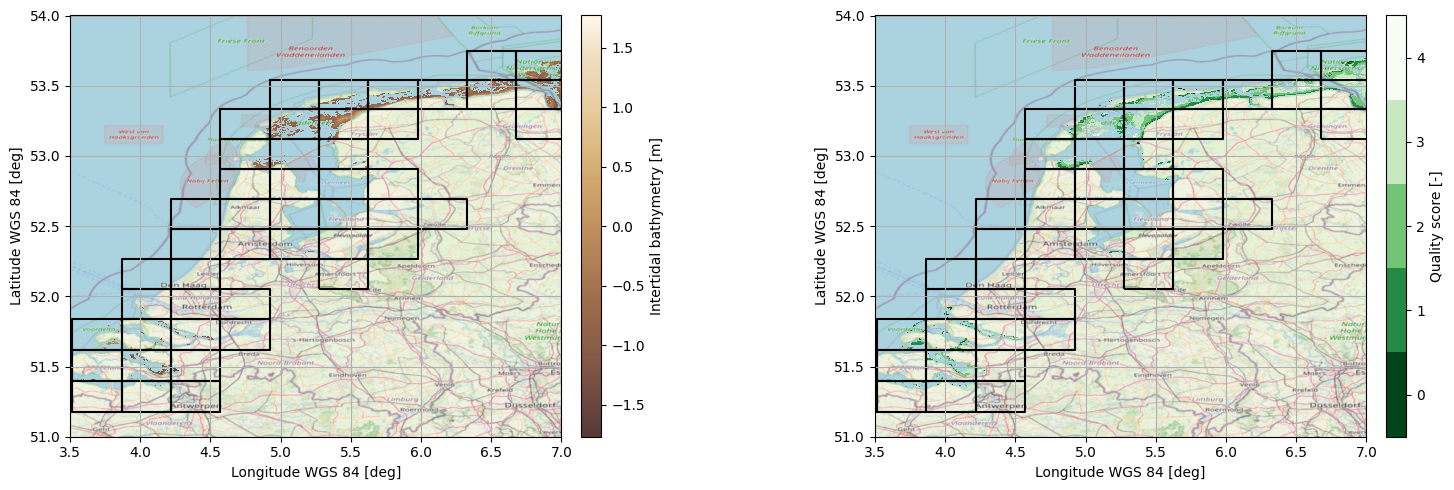

In [76]:
fig, axs = rpc.subplots(1, 2, figsize=(16, 5))
axs = axs.flatten()
rpc.imshow(ds_sdb_nl.isel(band=0), ax=axs[0], data_style='default', center=0, cmap=cmaps.brown_sable, cbar_kwargs={'label': 'Intertidal bathymetry [m]'})
p = rpc.imshow(ds_sdb_nl.isel(band=1), ax=axs[1], data_style='default', vmin=-0.5, vmax=4.5,
              cmap=mpl.colormaps['Greens_r'].resampled(5), cbar_kwargs={'label': 'Quality score [-]'})
p.colorbar.set_ticks(range(0, 5))
for ax in axs:
    rpc.geometries(gdf_tiles_nl, ax=ax, geom_style='tiles')
    rpc.basemap(crs=crs, ax=ax, map_style='osm', extent_style='netherlands')
rpc.show(fig=fig)

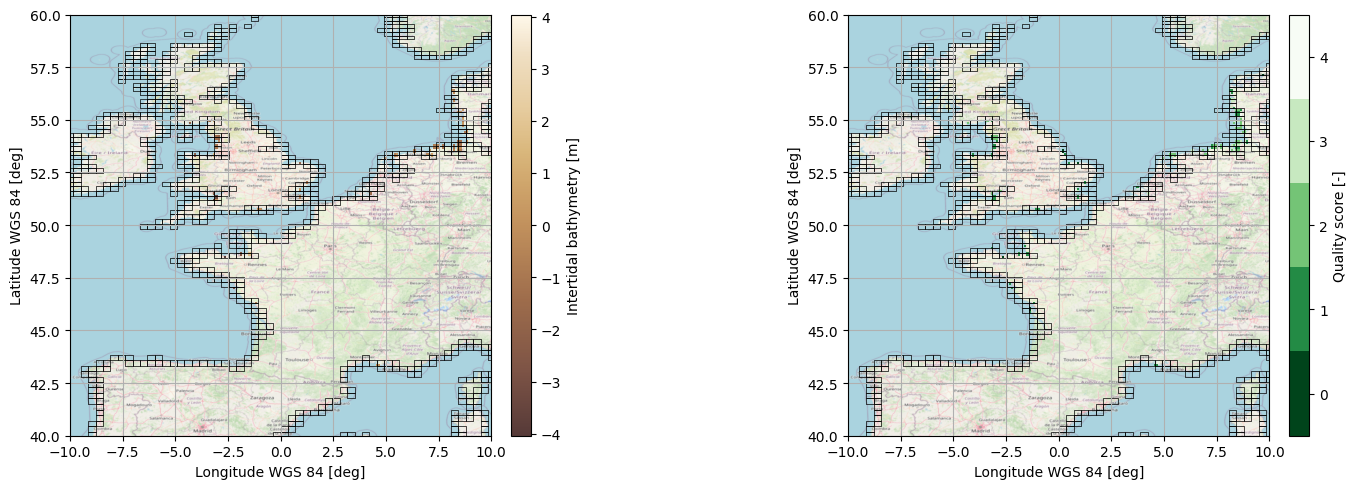

In [77]:
fig, axs = rpc.subplots(1, 2, figsize=(16, 5))
axs = axs.flatten()
rpc.imshow(ds_sdb_eu.isel(band=0), ax=axs[0], data_style='default', center=0, cmap=cmaps.brown_sable, cbar_kwargs={'label': 'Intertidal bathymetry [m]'})
p = rpc.imshow(ds_sdb_eu.isel(band=1), ax=axs[1], data_style='default', vmin=-0.5, vmax=4.5,
              cmap=mpl.colormaps['Greens_r'].resampled(5), cbar_kwargs={'label': 'Quality score [-]'})
p.colorbar.set_ticks(range(0, 5))
for ax in axs:
    rpc.geometries(gdf_tiles_eu, ax=ax, geom_style='tiles', linewidth=0.5)
    rpc.basemap(crs=crs, ax=ax, map_style='osm', extent_style='europe')
rpc.show(fig=fig)